# This notebook shows how to compute the Z2 topological invariant of a time-reversal-invariant 2D insulator via Wannier-charge-center pumping, on monolayer graphene with enhanced intrinsic spin-orbit coupling
### Import the necessary libraries

In [1]:
%matplotlib inline
import re
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### The non-Abelian Wilson loop and Wannier charge centers
$$ F_i(k_2)=\langle\psi(k_1^{(i)},k_2)|\psi(k_1^{(i+1)},k_2)\rangle, \qquad D(k_2)=U(F_0)U(F_1)\cdots U(F_{N-1}) $$
$U(F)=UV^\dagger$ is the polar-decomposition unitarization of each link overlap (the multi-band generalization of the Fukui-Hatsugai-Suzuki single-band link variable, notebooks/05_berry_curvature.ipynb). $D(k_2)$'s eigenvalue phases $\theta_m(k_2)$ are the hybrid Wannier charge centers (WCCs). Sweeping the pumping momentum $k_2$ across only the time-reversal-invariant half Brillouin zone $[0,0.5]$ (Kramers-paired at both ends), the $\mathbb Z_2$ invariant $\nu\in\{0,1\}$ counts, mod 2, how many times the WCCs collectively cross the largest empty gap in their own spectrum (Yu, Qi, Bernevig, Fang & Dai, PRB 84, 075119 (2011); Soluyanov & Vanderbilt, PRB 83, 235401 (2011)).

### Monolayer graphene with enhanced intrinsic spin-orbit coupling
Kane & Mele's original prediction (PRL 95, 146802 (2005)): planar graphene is a quantum spin Hall insulator ($\nu=1$) for *any* nonzero intrinsic spin-orbit coupling. Real unscaled carbon SOC is far too weak ($\sim1\,\mu$eV) to resolve on a practical mesh, so `soc_scale` (per-species SOC scaling) enhances it here -- this changes only the size of the resulting gap, not which phase graphene is in.

In [2]:
A = 2.46 * 1.8897259886  # Bohr
VACUUM = 20.0
GRAPHENE_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, VACUUM)]
GRAPHENE_SPECIES = {"C": [(0.0, 0.0, 0.5), (1 / 3, 2 / 3, 0.5)]}

graphene = Structure(GRAPHENE_AVEC, GRAPHENE_SPECIES).get_calculation(
    "_scratch/graphene_z2", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0,
    spinorb=True, soc_scale={"C": 3000.0},  # 100x is real physics but too narrow a gap to resolve on a practical mesh (see docs/design.md #20)
)
graphene.get_energy()

first_block = (graphene.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 0.5 for o in occ)  # occupied count from EIGVAL.OUT, not an assumed electron count

In [3]:
result = graphene.get_z2_invariant(1, ist1, nkx=24, nt=13)
result["z2"]  # 0 (trivial) or 1 (quantum spin Hall)

1

### Wannier-center trajectories
Each occupied band's WCC as a function of the pumping momentum -- the occupied $\pi$ manifold's WCCs collectively wind across the largest-gap reference an odd number of times between $k_2=0$ and $k_2=0.5$, the graphical signature of $\nu=1$.

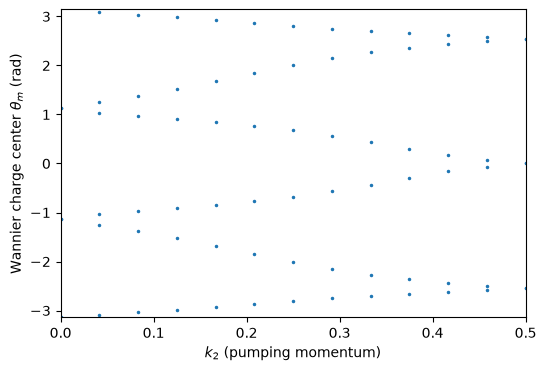

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
for band in range(result["wannier_centers"].shape[1]):
    ax.plot(result["pump"], result["wannier_centers"][:, band], ".", ms=3, color="C0")
ax.set_xlabel(r"$k_2$ (pumping momentum)")
ax.set_ylabel(r"Wannier charge center $\theta_m$ (rad)")
ax.set_xlim(0, 0.5)
ax.set_ylim(-np.pi, np.pi)
plt.show()

### A structurally distinct QSH system: buckled monolayer bismuth
Murakami's original QSH prediction (PRL 97, 236805 (2006)): freestanding buckled-honeycomb monolayer bismuth ("bismuthene") is topological due to bismuth's own large *atomic* spin-orbit coupling -- unlike graphene, no `soc_scale` enhancement is needed. Structure ($a=4.34$ Angstrom, buckling$=1.73$ Angstrom, Cheng et al., J. Phys. Chem. C 118, 904 (2014)); the band inversion driving the gap sits at $\Gamma$ here, not $K$ -- a genuinely different mechanism from graphene's Dirac-point picture.

In [5]:
A_BI = 4.34 * 1.8897259886  # Bohr
BUCKLING = 1.73 * 1.8897259886  # Bohr, vertical offset between the two sublattices
VACUUM_BI = 28.0
BI_AVEC = [(A_BI, 0.0, 0.0), (-A_BI / 2, A_BI * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, VACUUM_BI)]
half_delta = (BUCKLING / 2) / VACUUM_BI
BI_SPECIES = {"Bi": [(0.0, 0.0, 0.5 + half_delta), (1 / 3, 2 / 3, 0.5 - half_delta)]}

bismuthene = Structure(BI_AVEC, BI_SPECIES).get_calculation(
    "_scratch/bismuthene_z2", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0, spinorb=True,
)
bismuthene.get_energy()

first_block = (bismuthene.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1_bi = sum(o > 0.5 for o in occ)

In [6]:
result_bi = bismuthene.get_z2_invariant(1, ist1_bi, nkx=24, nt=13)
result_bi["z2"]  # 1: quantum spin Hall, matching Murakami's prediction

1